<a href="https://colab.research.google.com/github/dr-koehler-ai/ICU-Mortality-Prediction/blob/main/Early_ICU_Mortality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Clinical Question*: Can routinely available clinical data from the first 24 hours of ICU admission predict in-hospital mortality?

In [16]:
# Clinical Sepsis Analytics Dashboard (V1)
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Statistics
from scipy import stats
from statistics import mean, stdev
from math import sqrt

# Data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Data modeling
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay


# =========================
# 1. Dataset Download
# =========================

from google.colab import drive
drive.mount("/content/drive")

dataset_path = Path("/content/drive/MyDrive/AI_Healthcare/ICU_Mortality_Prediction/training_v2.csv")

data = pd.read_csv(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Dataset Overview**


*   Number of rows and attributes
*   For each of the 01713 patients a total number of 186 attributes was collected, including ids, admission information, apache-scores, clinical and laboratory results of the first hour and day.



In [17]:
print("\nShape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nPatients:", data["patient_id"].nunique())


Shape: (91713, 186)

Columns: ['encounter_id', 'patient_id', 'hospital_id', 'hospital_death', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_mi

In [45]:
audit = pd.DataFrame({
    "dtype": data.dtypes,
    "missing_n": data.isna().sum(),
    "missing_pct": data.isna().mean().mul(100),
    "n_unique": data.nunique()
})

display(audit.loc[
    ["encounter_id", "patient_id", "hospital_id", "hospital_death"]
])

print("Doppelte encounter_id:", data["encounter_id"].duplicated().sum())
print("Doppelte patient_id:", data["patient_id"].duplicated().sum())
print("Zielwerte einschließlich fehlender Werte:")
print(data["hospital_death"].value_counts(dropna=False))

display(audit.loc[audit["n_unique"] <= 1])

,dtype,missing_n,missing_pct,n_unique
encounter_id,int64,0,0.0,91713
patient_id,int64,0,0.0,91713
hospital_id,int64,0,0.0,147
hospital_death,int64,0,0.0,2


Doppelte encounter_id: 0
Doppelte patient_id: 0
Zielwerte einschließlich fehlender Werte:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


,dtype,missing_n,missing_pct,n_unique
readmission_status,int64,0,0.0,1


**2. Missing Data Analysis and Checking for Duplicates**

In [18]:
# =========================
# 2. Missing Data Analysis
# =========================

missing = data.isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(50))

print(data.duplicated().sum())
print("There are no duplicates")


Top Missing Values:
 h1_bilirubin_min          0.922650
h1_bilirubin_max          0.922650
h1_lactate_min            0.919924
h1_lactate_max            0.919924
h1_albumin_max            0.913982
h1_albumin_min            0.913982
h1_pao2fio2ratio_min      0.874413
h1_pao2fio2ratio_max      0.874413
h1_arterial_ph_max        0.833295
h1_arterial_ph_min        0.833295
h1_hco3_max               0.829697
h1_hco3_min               0.829697
h1_arterial_pco2_max      0.828225
h1_arterial_pco2_min      0.828225
h1_wbc_max                0.828160
h1_wbc_min                0.828160
h1_arterial_po2_min       0.828072
h1_arterial_po2_max       0.828072
h1_calcium_max            0.827178
h1_calcium_min            0.827178
h1_platelets_min          0.825107
h1_platelets_max          0.825107
h1_bun_max                0.818761
h1_bun_min                0.818761
h1_creatinine_max         0.817300
h1_creatinine_min         0.817300
h1_diasbp_invasive_max    0.816983
h1_diasbp_invasive_min    0.81698

**3. Analysis of Target Variable**


*   With a mortality rate of 8,6%, 7915 of the 91713 patients died in-hospital. Thus, we deal with a highly imbalanced dataset.



Outcome distribution:
hospital_death
0    83798
1     7915
Name: count, dtype: int64
Mortality rate: 8.6%


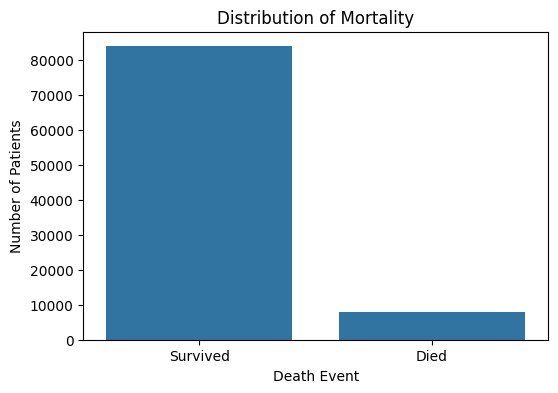

In [19]:
# =========================
# 3. Target Variable
# =========================

print("Outcome distribution:")
print(data["hospital_death"].value_counts())
mortality_rate = data["hospital_death"].mean()

print(f"Mortality rate: {mortality_rate:.1%}")
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x="hospital_death"
)

plt.title("Distribution of Mortality")
plt.xlabel("Death Event")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Survived", "Died"])
plt.show()

**4. Univariate Analysis of Continious Variables**

*   Histogramms
*   Boxplots
*   EDA was focused on demographic and clinical variables as well as clinical and laboratory measurements within the first day, due to the many missing values in the first hour.
*   APACHE-score was discarded, due to the fact that it already incooperates many factors as a rating system for ICU-death.
*   Relevant variables of d1 were chosen based on missingness and clinical relevance.

In [39]:
data.columns.to_list()

demographic_vars = ['age',
 'bmi']

clinical_vars = ['gender',
 'ethnicity',
 'elective_surgery',
 'aids',
 'cirrhosis',
 'diabetes_mellitus',
 'hepatic_failure',
 'immunosuppression',
 'leukemia',
 'lymphoma',
 'solid_tumor_with_metastasis']

apache_vars = [
 'albumin_apache',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bilirubin_apache',
 'bun_apache',
 'creatinine_apache',
 'fio2_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'paco2_apache',
 'paco2_for_ph_apache',
 'pao2_apache',
 'ph_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'urineoutput_apache',
 'ventilated_apache',
 'wbc_apache']

d1_vars = [
 'd1_heartrate_max',
 'd1_heartrate_min',
 'd1_mbp_max',
 'd1_mbp_min',
 'd1_resprate_max',
 'd1_resprate_min',
 'd1_spo2_min',
 'd1_sysbp_max',
 'd1_sysbp_min',
 'd1_temp_max',
 'd1_temp_min',
 'd1_albumin_min',
 'd1_bilirubin_max',
 'd1_bun_max',
 'd1_calcium_max',
 'd1_calcium_min',
 'd1_creatinine_max',
 'd1_glucose_max',
 'd1_glucose_min',
 'd1_hco3_max',
 'd1_hco3_min',
 'd1_hemaglobin_max',
 'd1_hemaglobin_min',
 'd1_inr_max',
 'd1_lactate_max',
 'd1_platelets_max',
 'd1_platelets_min',
 'd1_potassium_max',
 'd1_potassium_min',
 'd1_sodium_max',
 'd1_sodium_min',
 'd1_wbc_max',
 'd1_wbc_min',
 'd1_arterial_pco2_max',
 'd1_arterial_ph_min',
 'd1_arterial_po2_min',
 'd1_pao2fio2ratio_min']

missing = data[d1_vars].isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(50))

variable_labels = {
    "age": "Age (Years)",
    "bmi": "BMI (kilograms/metres^2)",
    "ethnicity": "Ethnicity",
    "gender": "Gender",
    "elective_surgery": "Elective Surgery",
    "aids": "AIDS",
    "cirrhosis": "Cirrhosis",
    "diabetes_mellitus": "Diabetes Mellitus",
    "hepatic_failure": "Hepatic Failure",
    "immunosuppression": "Immunosuppression",
    "leukemia": "Leukemia",
    "lymphoma": "Lymphoma",
    "solid_tumor_with_metastasis": "Solid Tumor with Metastasis",
    "d1_heartrate_max": "Maximum Heartrate (bpm)",
    "d1_heartrate_min": "Minimum Heartrate (bpm)",
    "d1_mbp_max": "Maximum Mean Blood Pressure (mmHg)",
    "d1_mbp_min": "Minimum Mean Blood Pressure (mmHg)",
    "d1_resprate_max": "Maximum Respiratory Rate (breaths/min)",
    "d1_resprate_min": "Minimum Respiratory Rate (breaths/min)",
    "d1_spo2_min": "Minimum Blood Oxygen Saturation (%)",
    "d1_sysbp_max": "Maximum Systolic Blood Pressure (mmHg)",
    "d1_sysbp_min": "Minimum Systolic Blood Pressure (mmHg)",
    "d1_temp_max": "Maximum Temperature (°C)",
    "d1_temp_min": "Minimum Temperature (°C)",
    "d1_albumin_min": "Minimum Albumin (g/L)",
    "d1_bilirubin_max": "Maximum Bilirubin (µmol/l)",
    "d1_bun_max": "Urea Nitrogen (mmol/l)",
    "d1_calcium_max": "Maximum Calcium (mmol/l)",
    "d1_calcium_min": "Minimum Calcium (mmol/l)",
    "d1_creatinine_max": "Maximum Creatinine (µmol/l)",
    "d1_glucose_max": "Maximum Glucose (mmol/l)",
    "d1_glucose_min": "Minimum Glucose (mmol/l)",
    "d1_hco3_max": "Maximum Bicarbonat (mmol/l)",
    "d1_hco3_min": "Minimum Bicarbonat (mmol/l)",
    "d1_hemaglobin_max": "Maximum Hemoglobin (g/dl)",
    "d1_hemaglobin_min": "Minimum Hemoglobin (g/dl)",
    "d1_inr_max": "Maximum INR",
    "d1_lactate_max": "Maximum Lactate (mmol/l)",
    "d1_platelets_max": "Maximum Platelets (×10^9/L)",
    "d1_platelets_min": "Minimum Platelets (×10^9/L)",
    "d1_potassium_max": "Maximum Potassium (mmol/l)",
    "d1_potassium_min": "Minimum Potassium (mmol/l)",
    "d1_sodium_max": "Maximum Sodium (mmol/l)",
    "d1_sodium_min": "Minimum Sodium (mmol/l)",
    "d1_wbc_max": "Maximum White Blood Cell Count (×10^9/L)",
    "d1_wbc_min": "Minimum White Blood Cell Count (×10^9/L)",
    "d1_arterial_pco2_max": "Maximum Arterial PCO2 (mmHg)",
    "d1_arterial_ph_min": "Minimum Arterial pH",
    "d1_arterial_po2_min": "Minimum Arterial PO2 (mmHg)",
    "d1_pao2fio2ratio_min": "Minimum PaO2/FiO2 Ratio"
}


Top Missing Values:
 d1_lactate_max          0.745761
d1_pao2fio2ratio_min    0.719723
d1_arterial_ph_min      0.655556
d1_arterial_pco2_max    0.646266
d1_arterial_po2_min     0.646168
d1_inr_max              0.631764
d1_bilirubin_max        0.585228
d1_albumin_min          0.535322
d1_hco3_min             0.164328
d1_hco3_max             0.164328
d1_platelets_max        0.146588
d1_platelets_min        0.146588
d1_wbc_min              0.143644
d1_wbc_max              0.143644
d1_calcium_min          0.142499
d1_calcium_max          0.142499
d1_hemaglobin_min       0.132446
d1_hemaglobin_max       0.132446
d1_bun_max              0.114640
d1_sodium_min           0.111162
d1_sodium_max           0.111162
d1_creatinine_max       0.110879
d1_potassium_min        0.104511
d1_potassium_max        0.104511
d1_glucose_max          0.063317
d1_glucose_min          0.063317
d1_temp_max             0.025340
d1_temp_min             0.025340
d1_resprate_max         0.004198
d1_resprate_min      

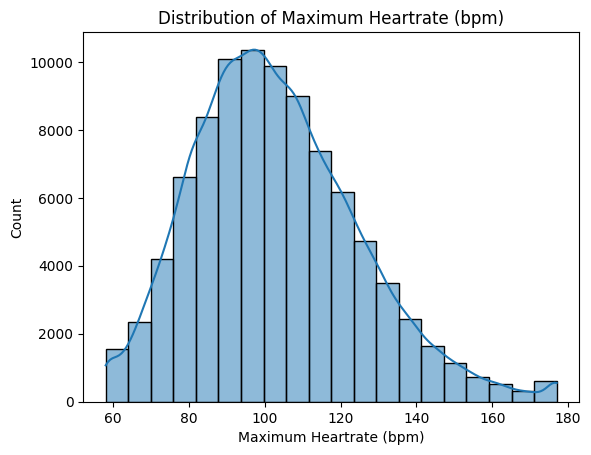

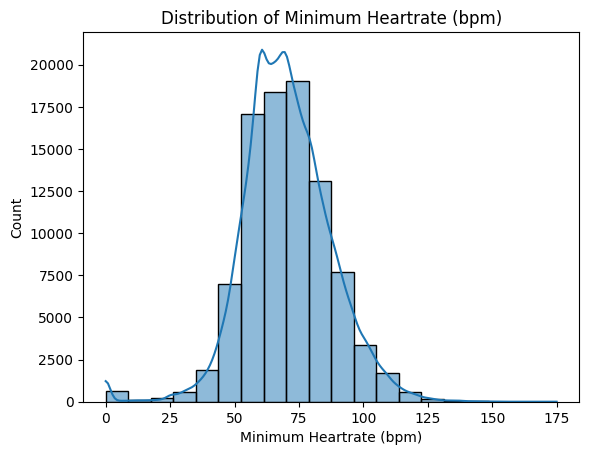

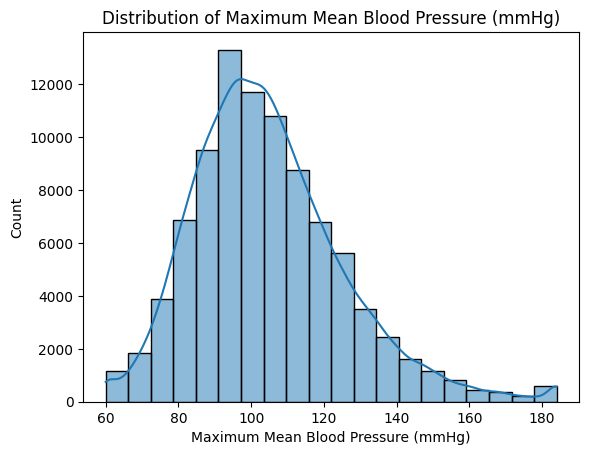

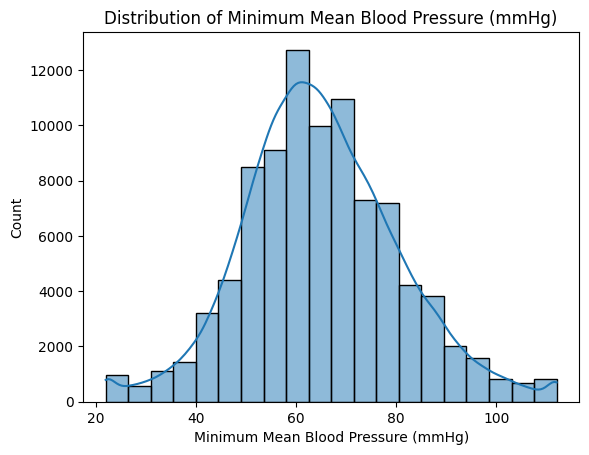

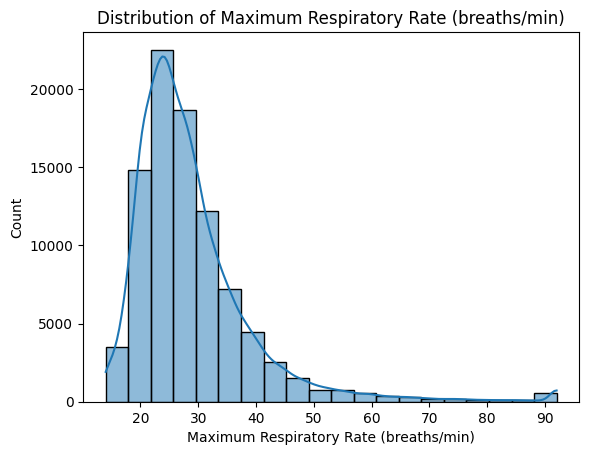

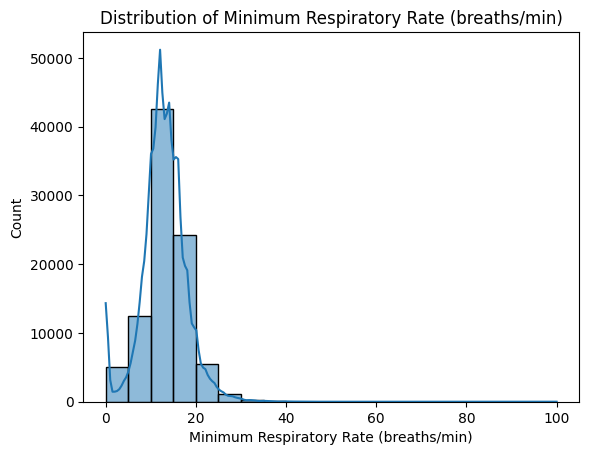

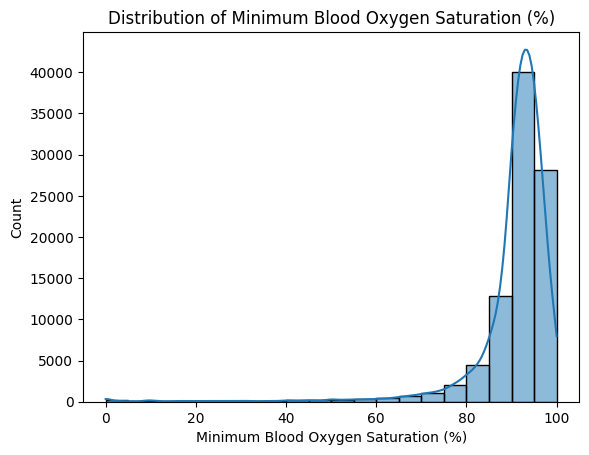

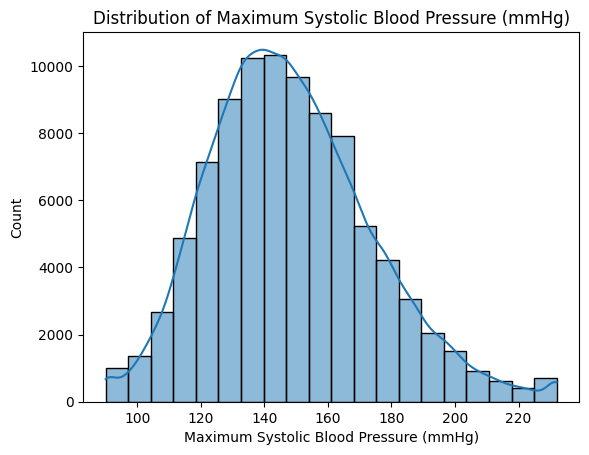

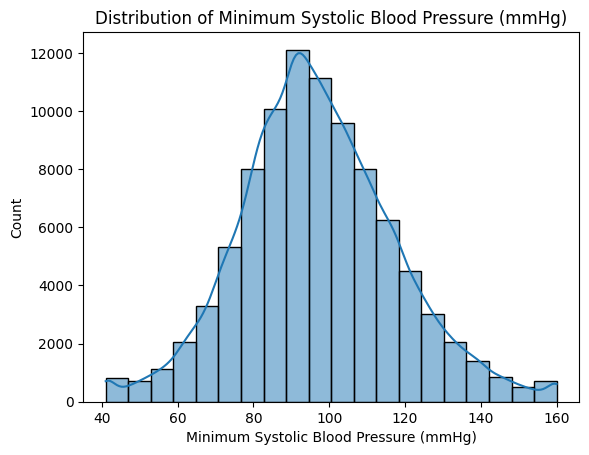

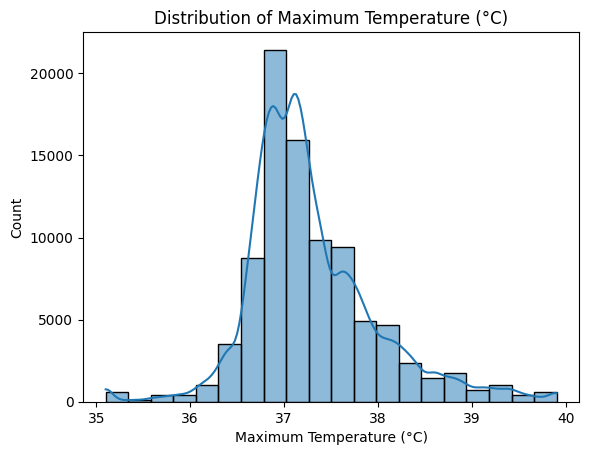

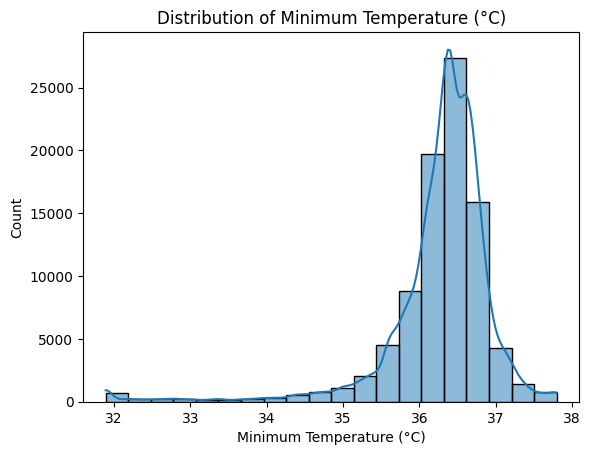

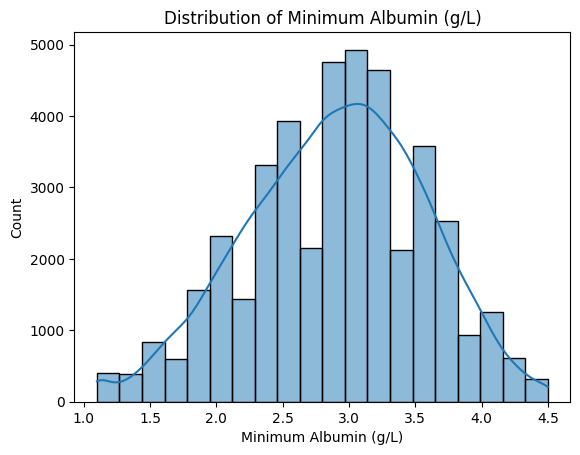

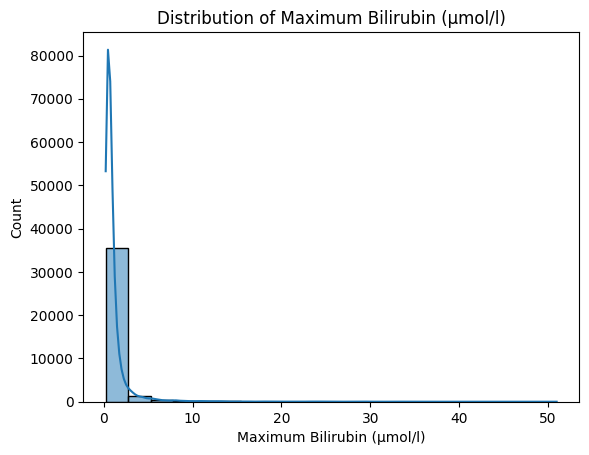

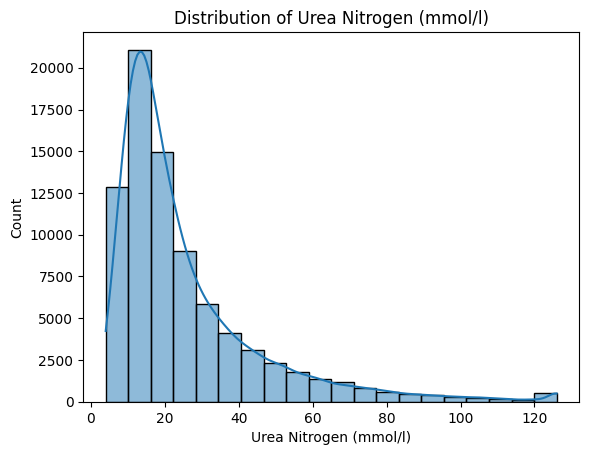

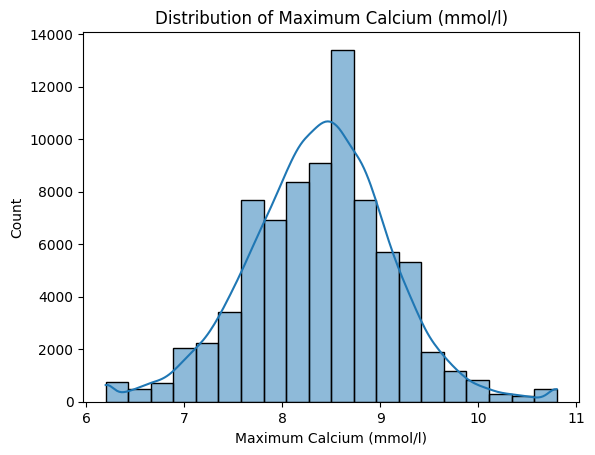

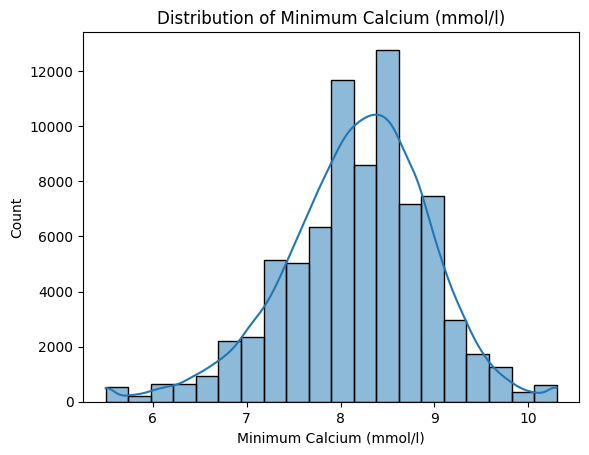

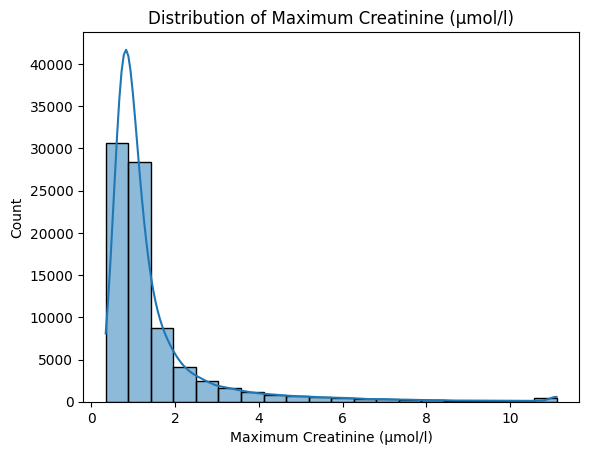

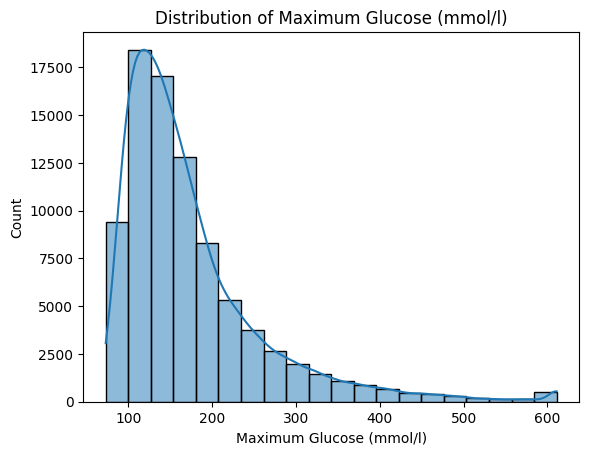

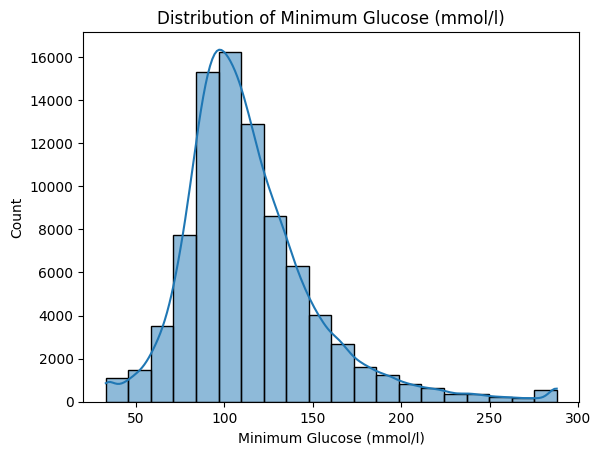

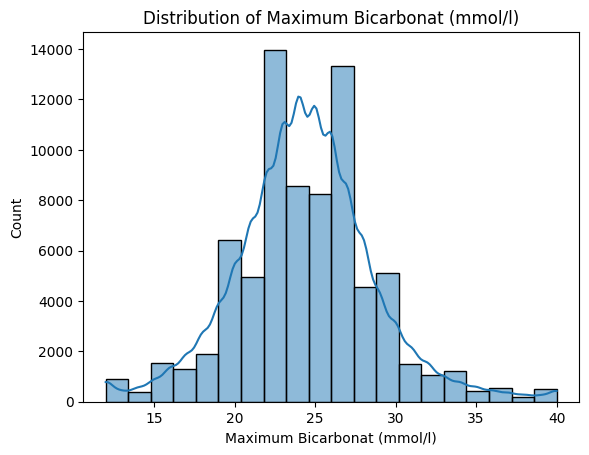

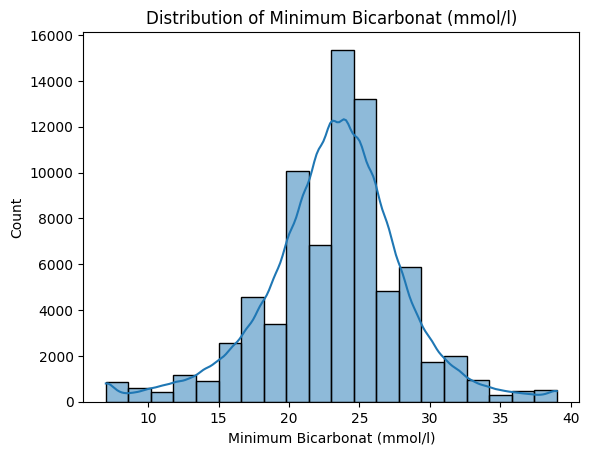

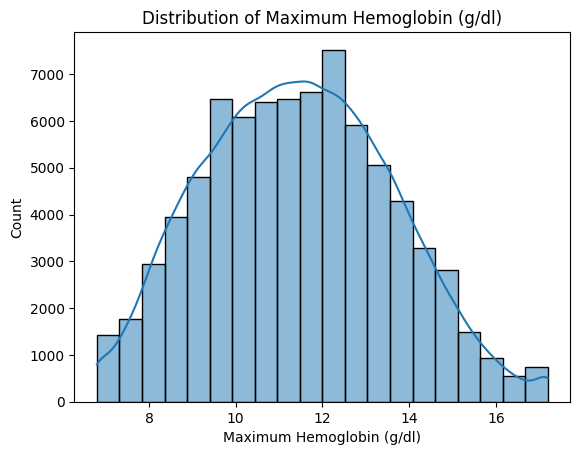

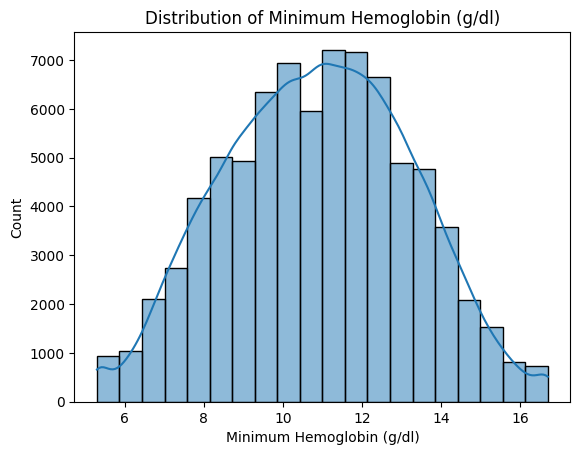

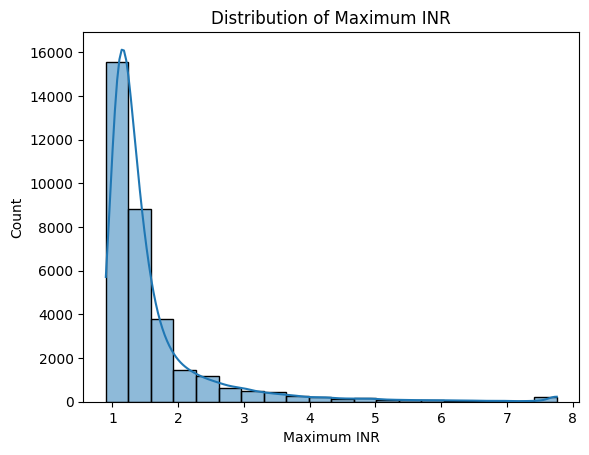

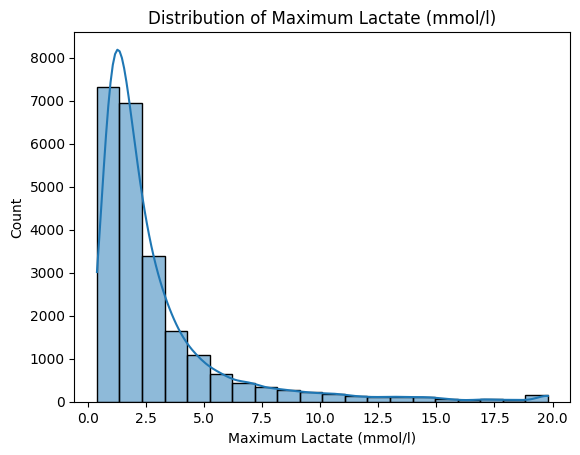

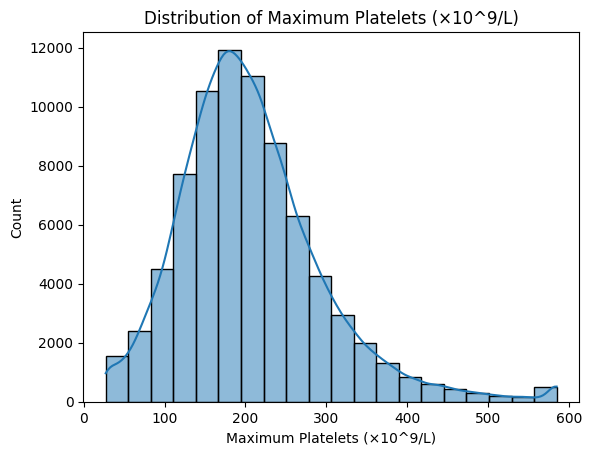

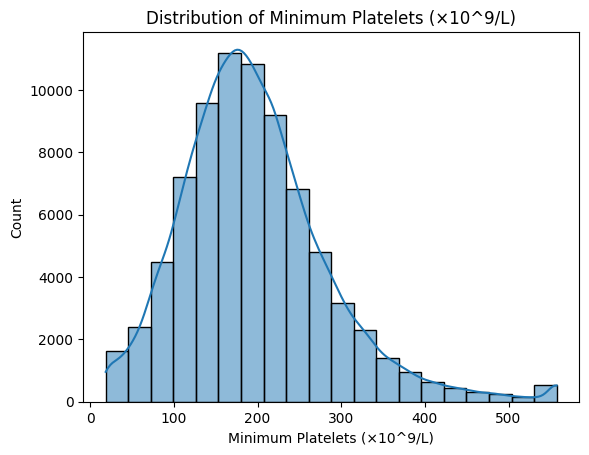

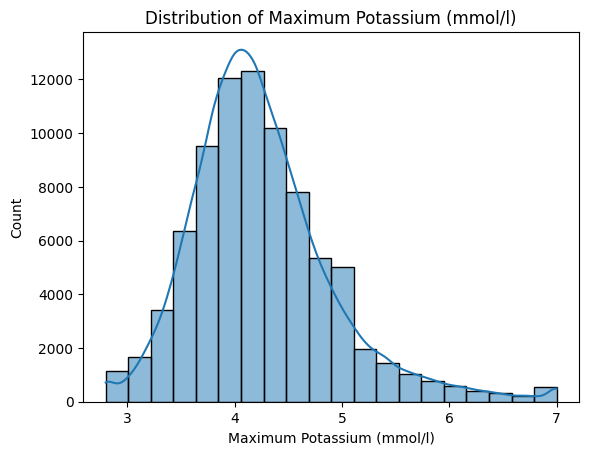

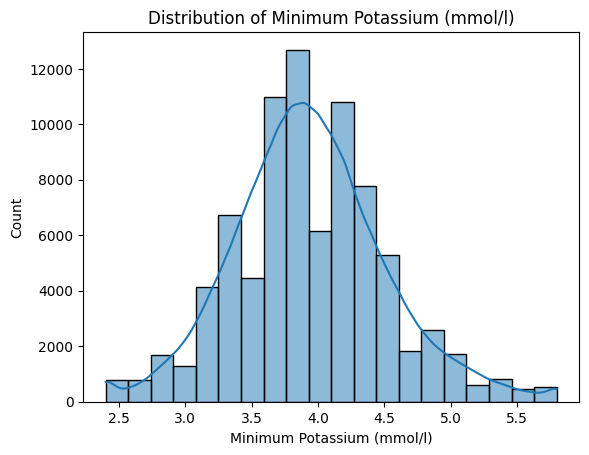

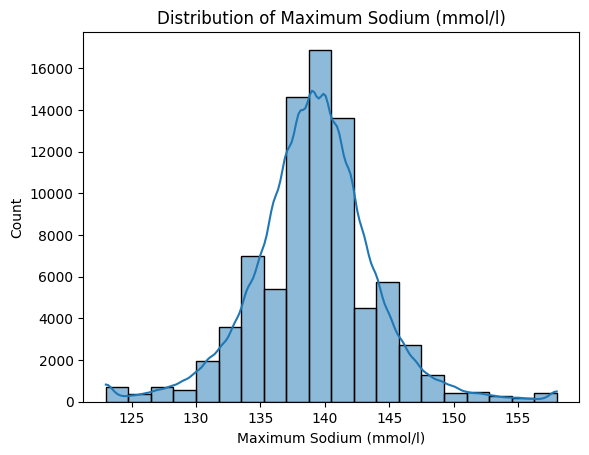

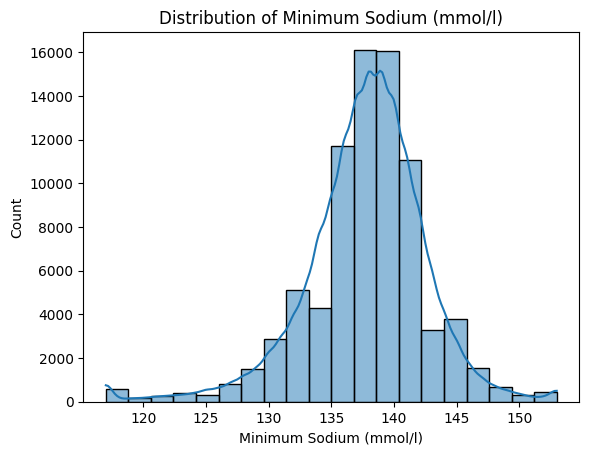

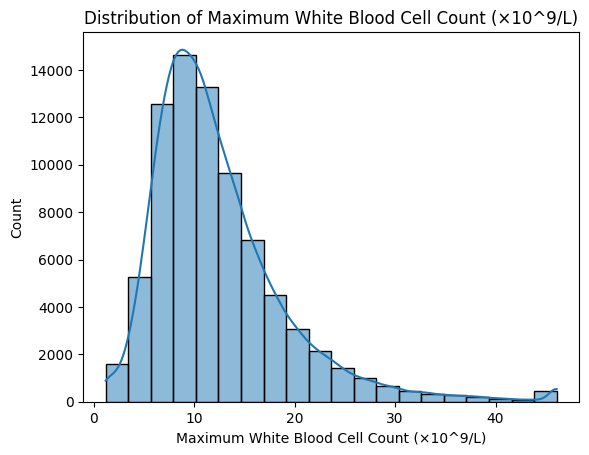

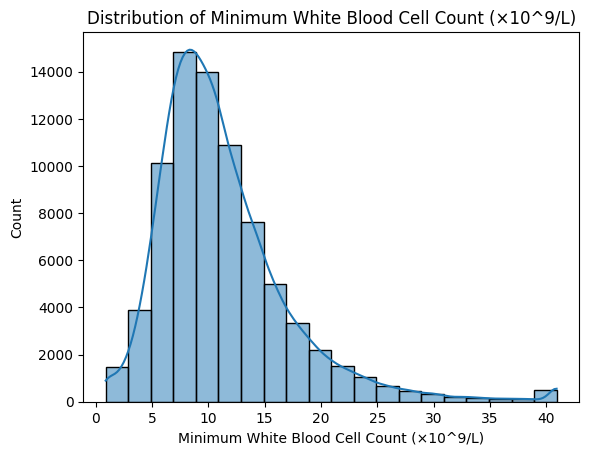

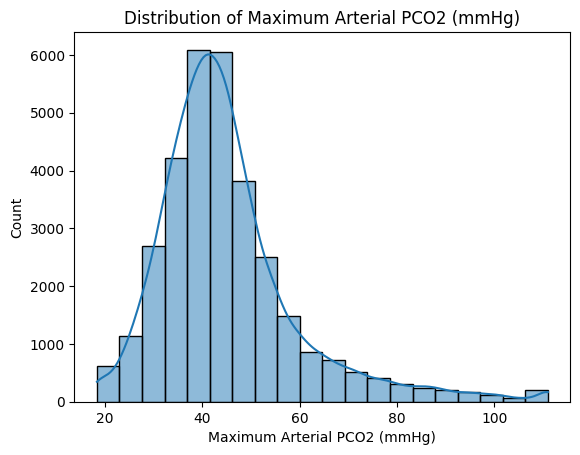

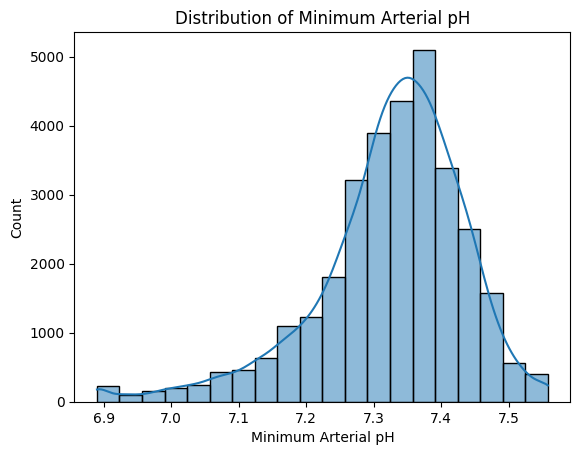

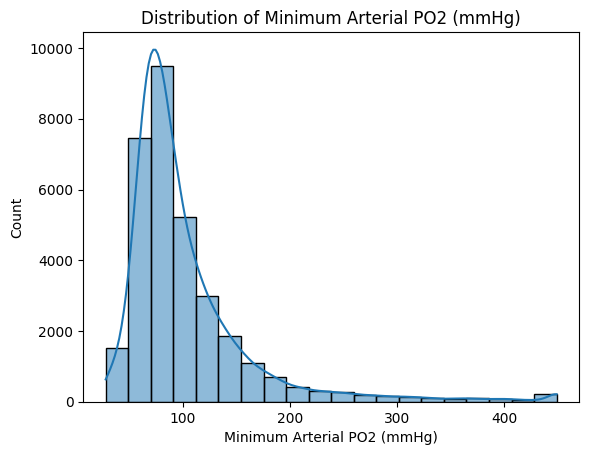

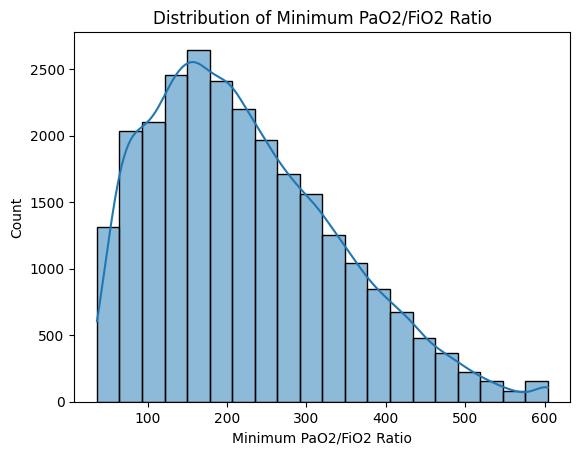

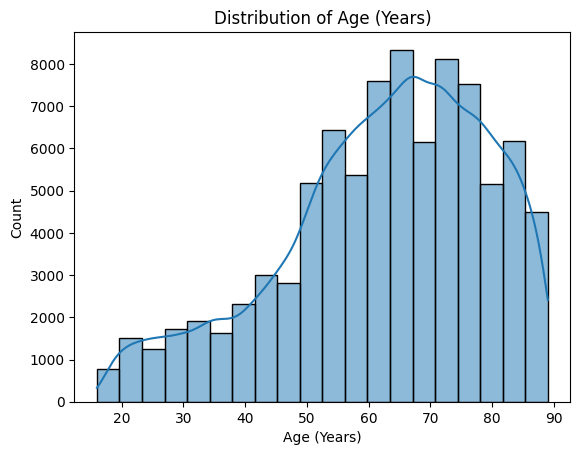

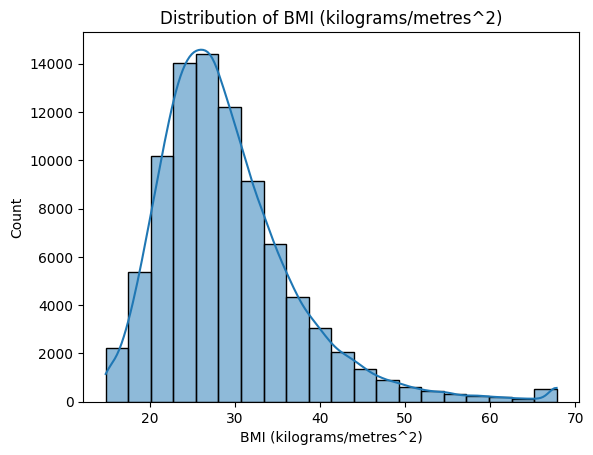

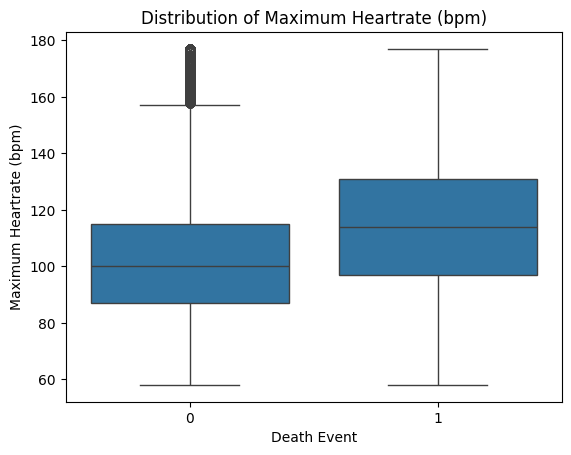

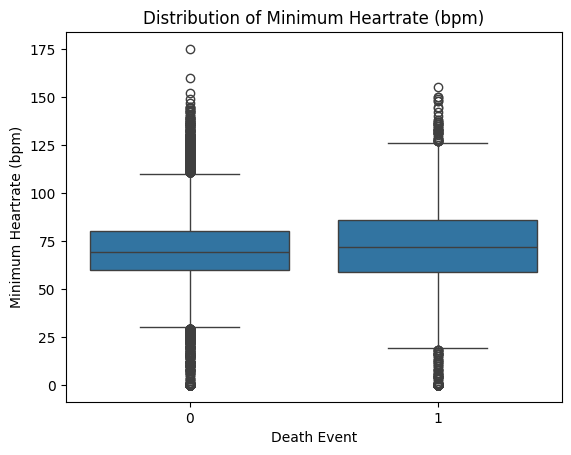

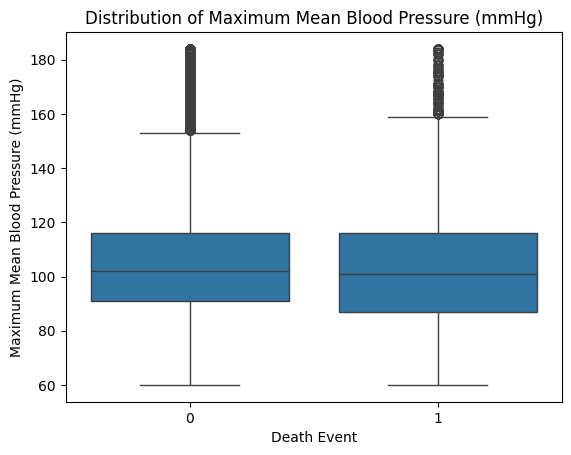

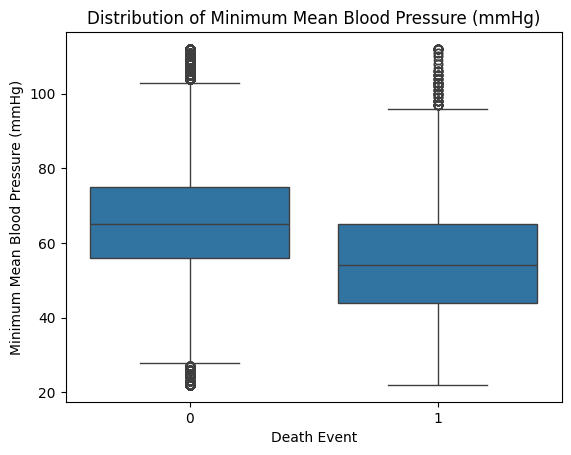

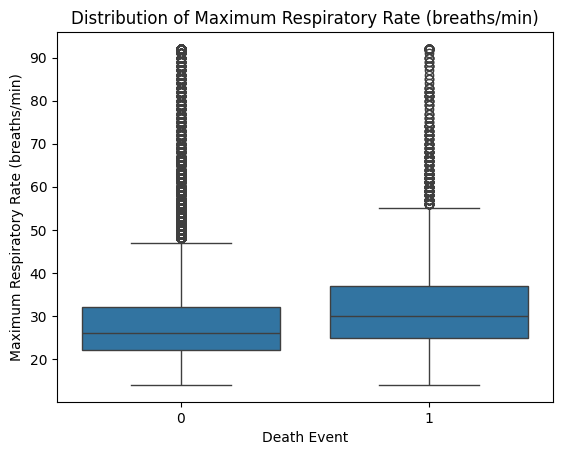

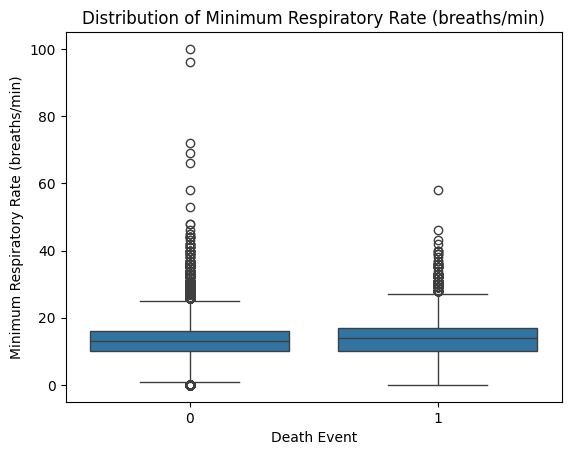

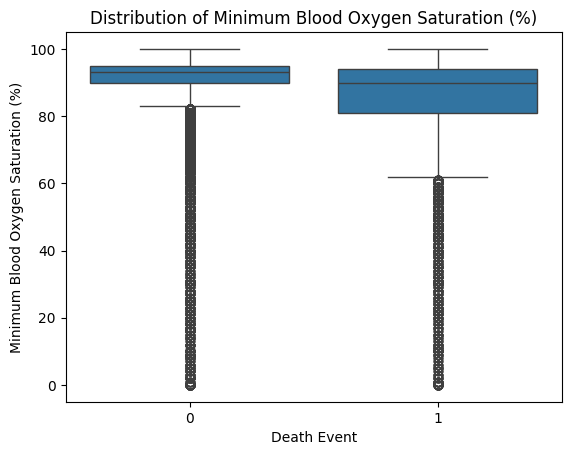

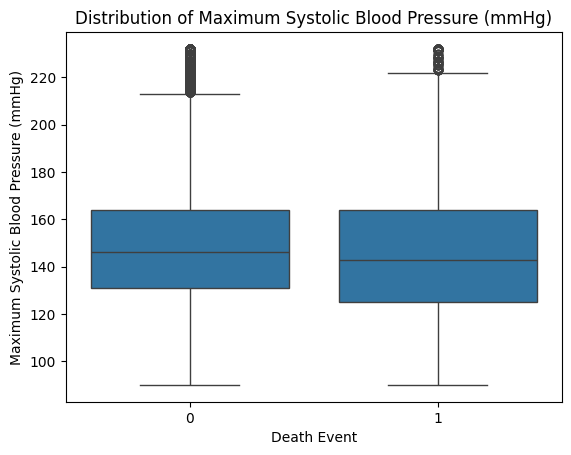

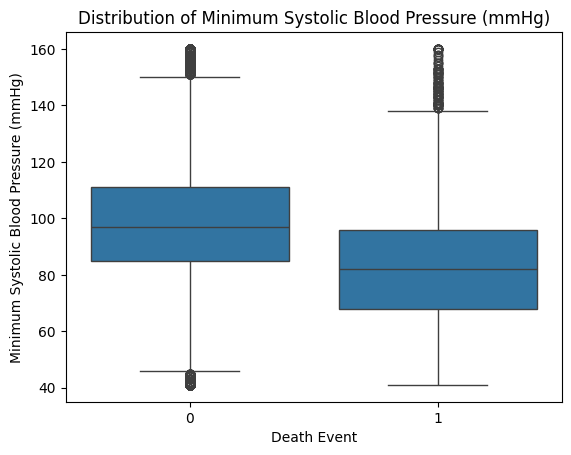

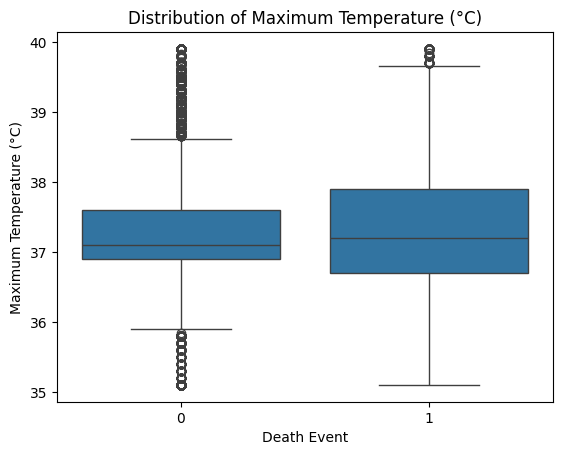

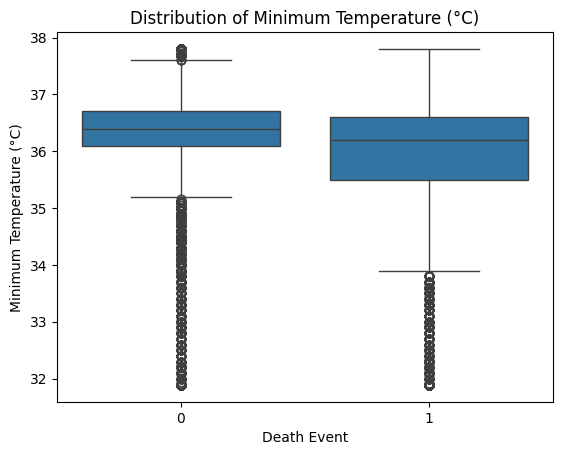

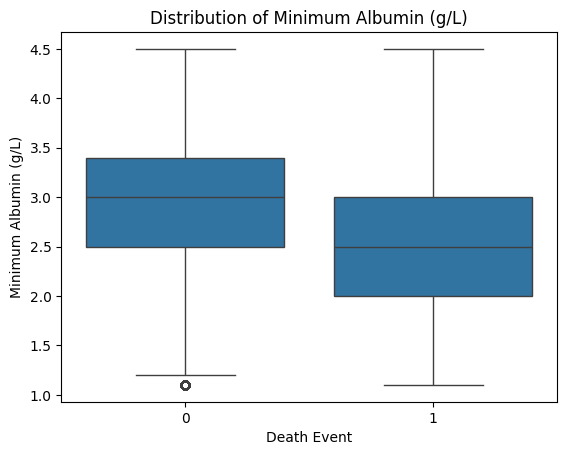

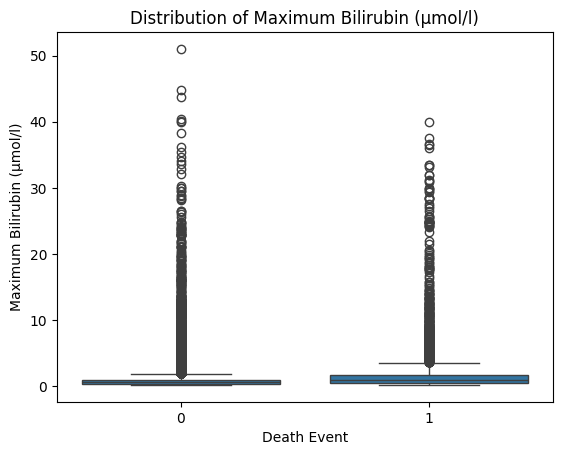

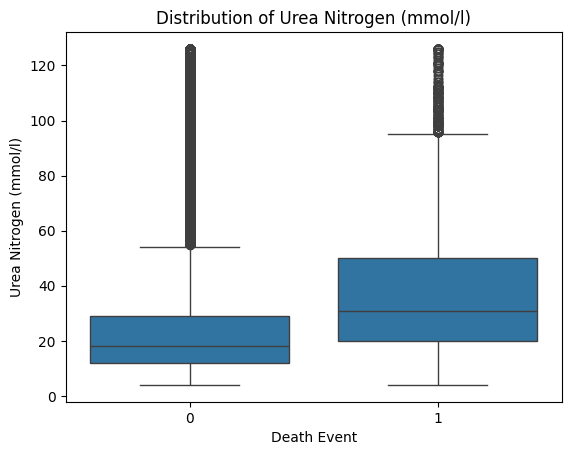

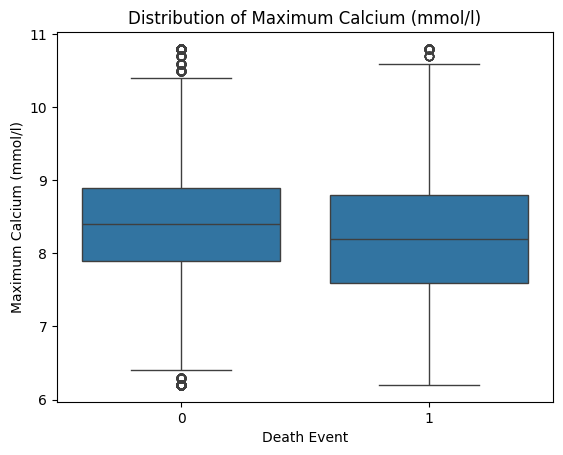

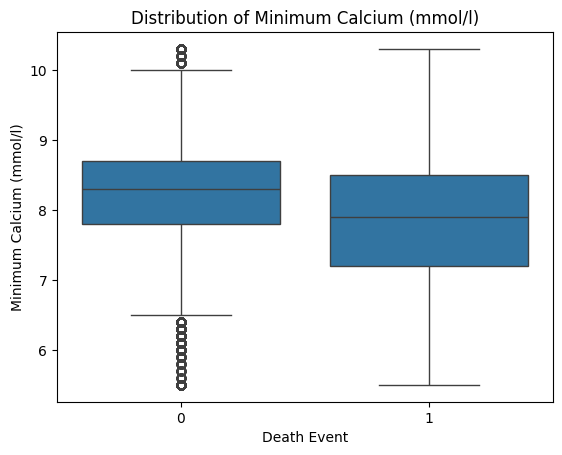

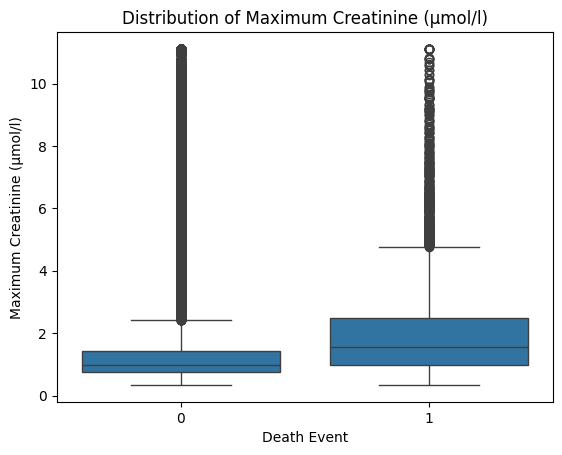

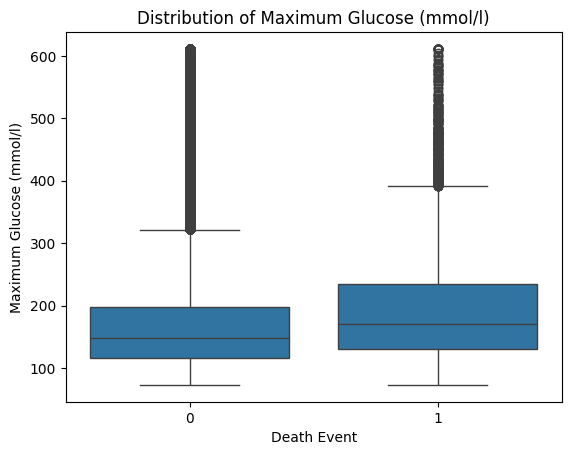

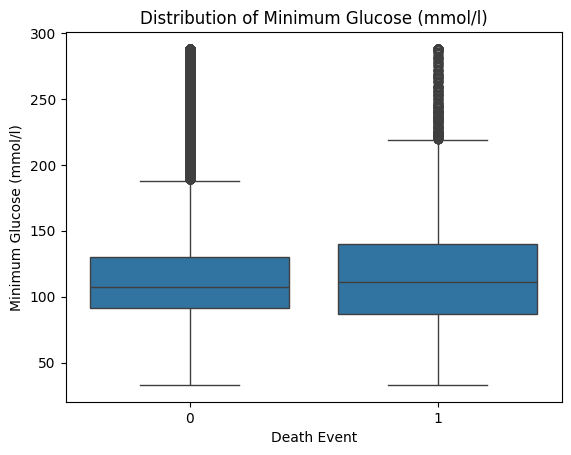

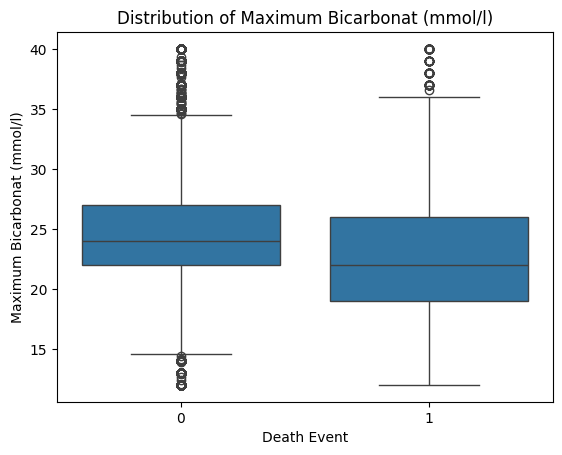

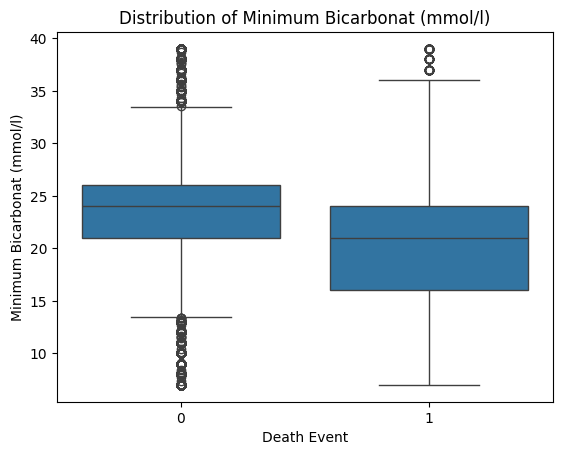

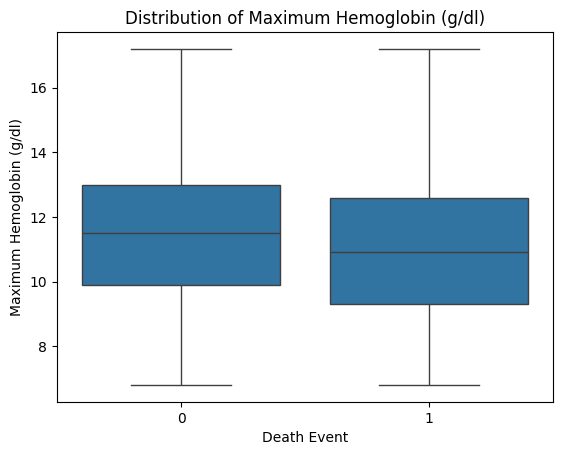

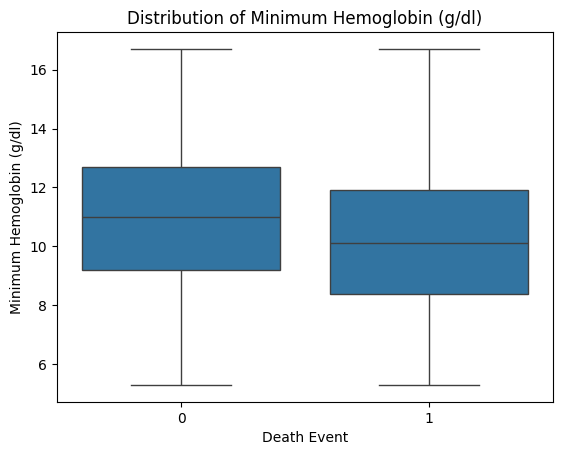

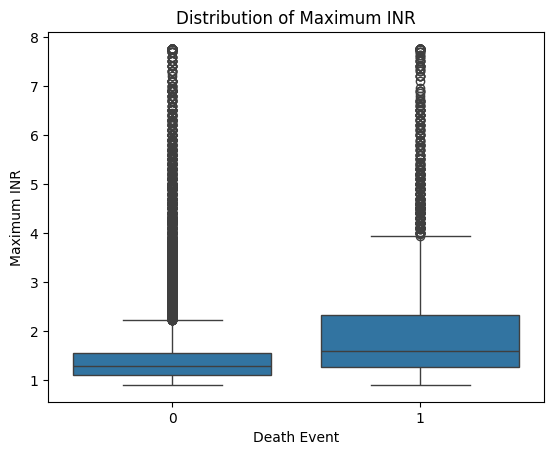

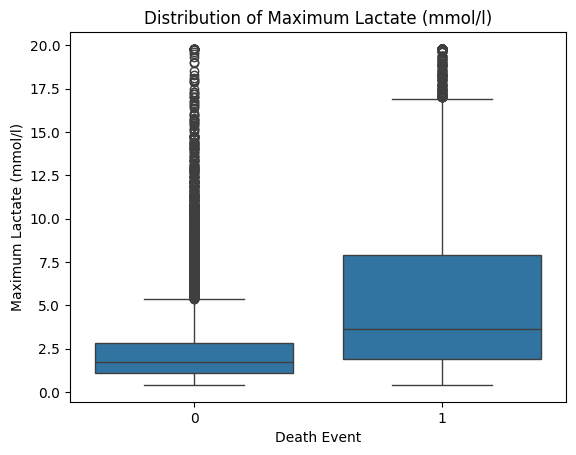

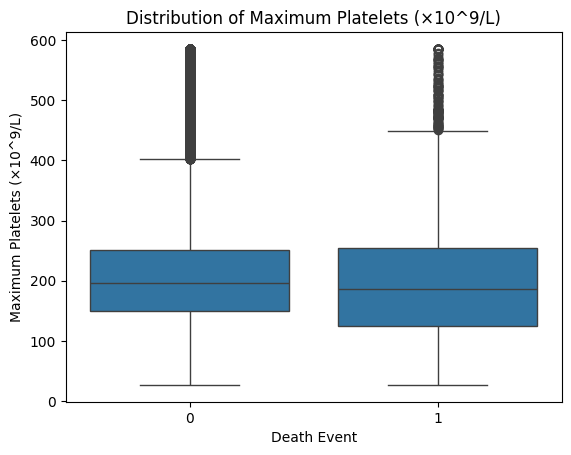

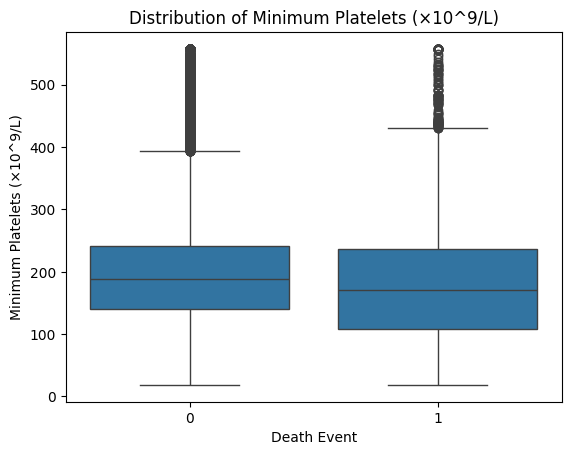

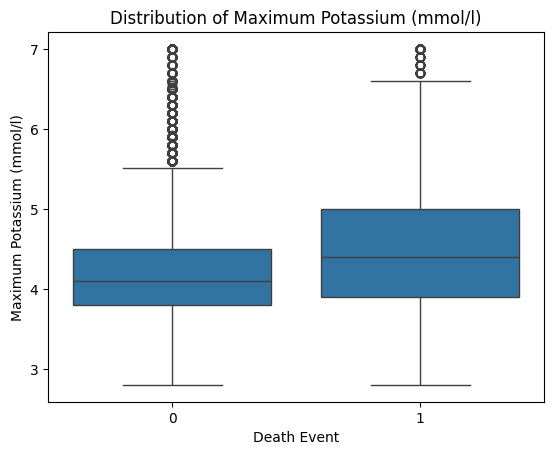

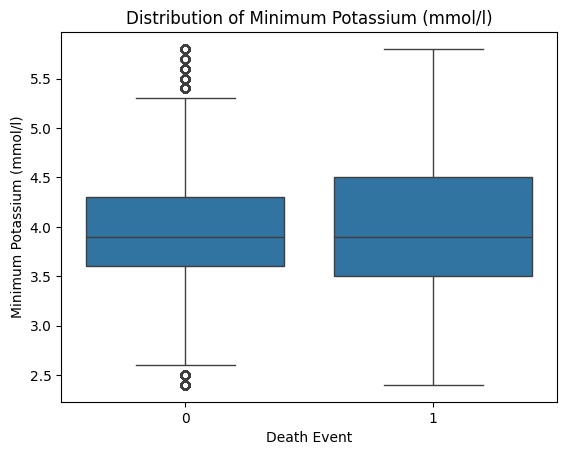

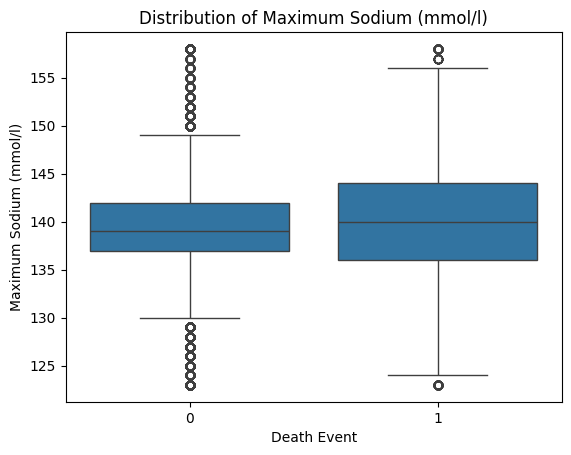

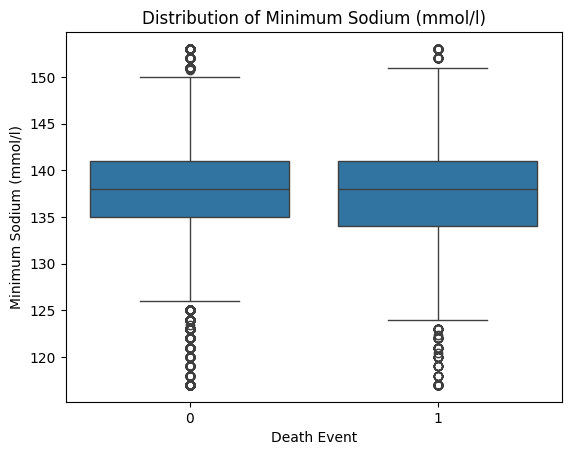

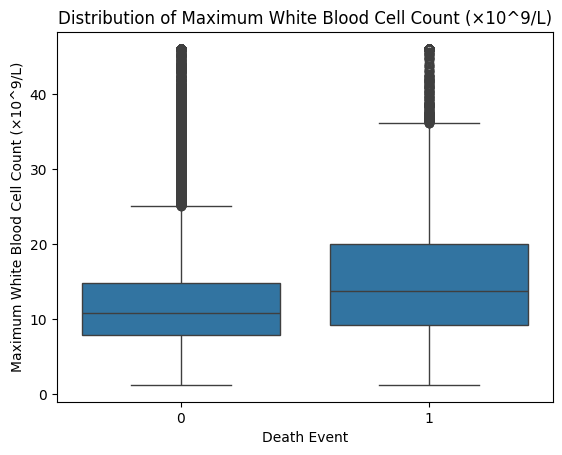

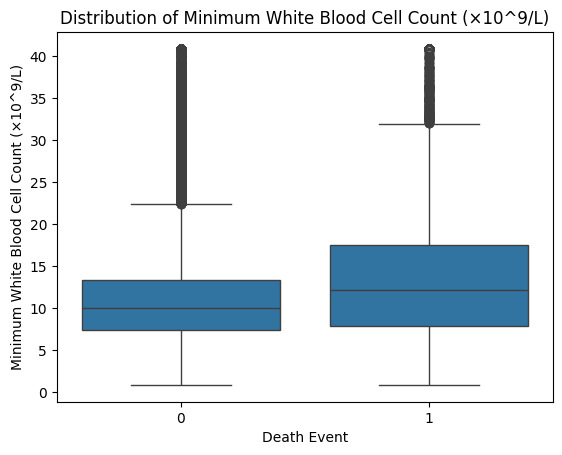

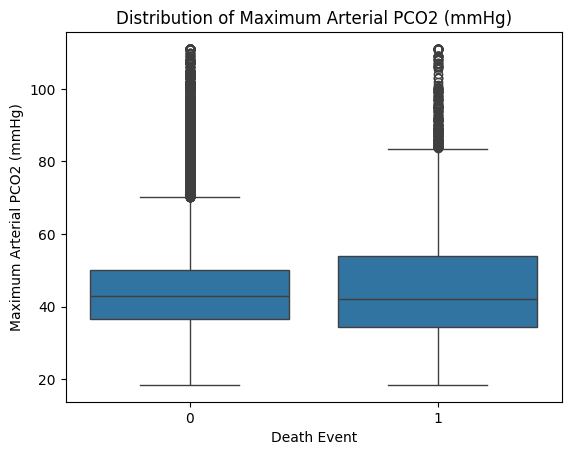

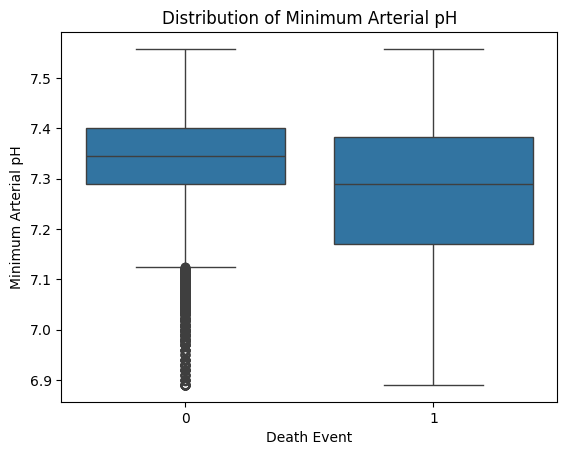

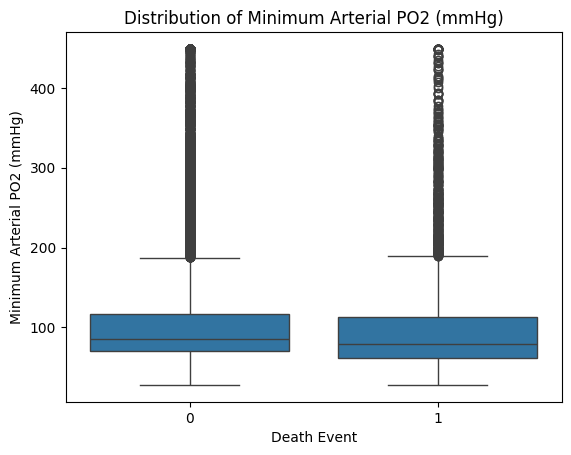

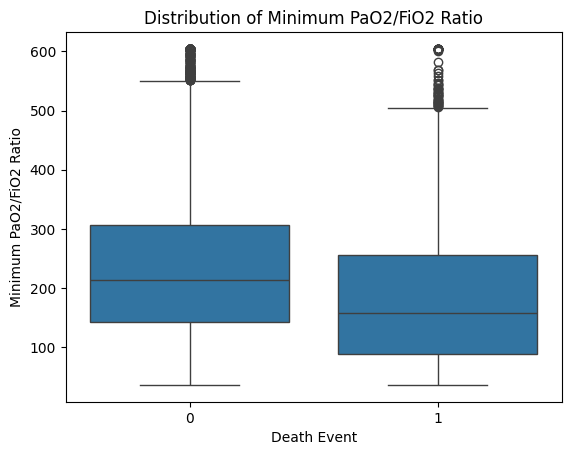

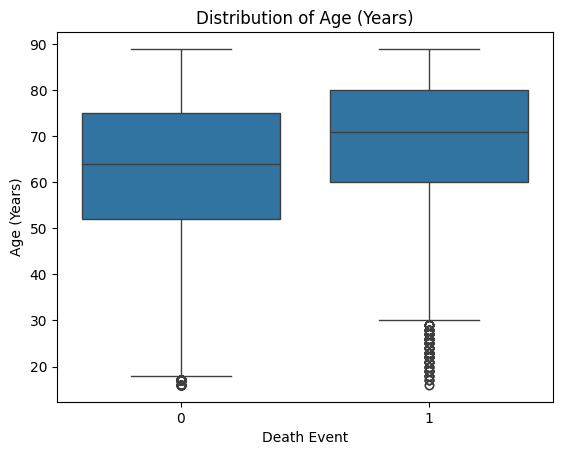

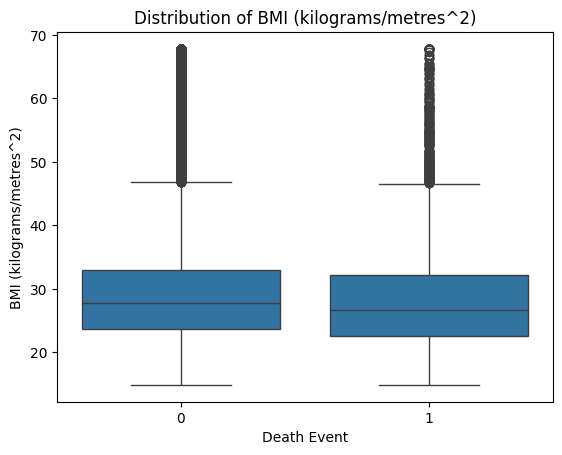

In [44]:
# ==================================================
# 4. Univariate Analysis
# ==================================================

def var_histograms(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    fig = sns.histplot(data=data, x=feat, bins=20, kde=True)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.show()
  return

var_histograms(d1_vars)
var_histograms(demographic_vars)

def var_boxplots(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    fig = sns.boxplot(data=data, x="hospital_death", y=feat)
    plt.title(f"Distribution of {label}")
    plt.xlabel("Death Event")
    plt.ylabel(label)
    plt.show()
  return

var_boxplots(d1_vars)
var_boxplots(demographic_vars)

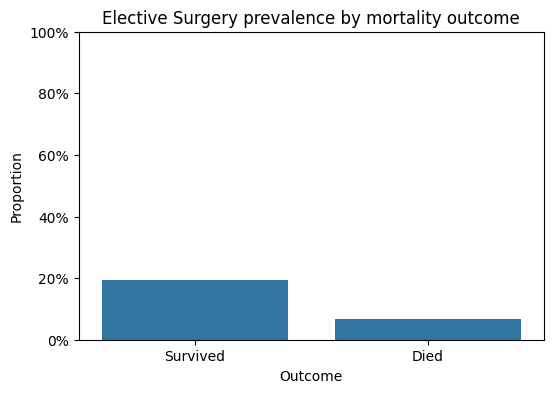

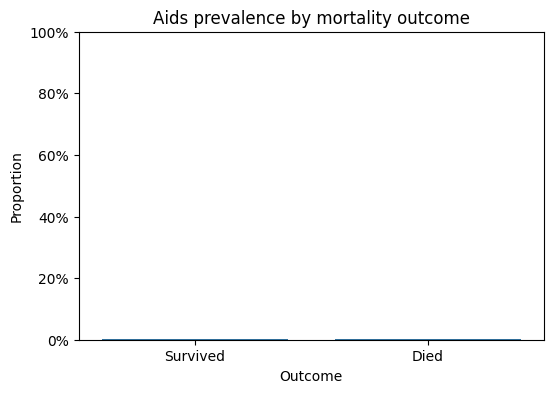

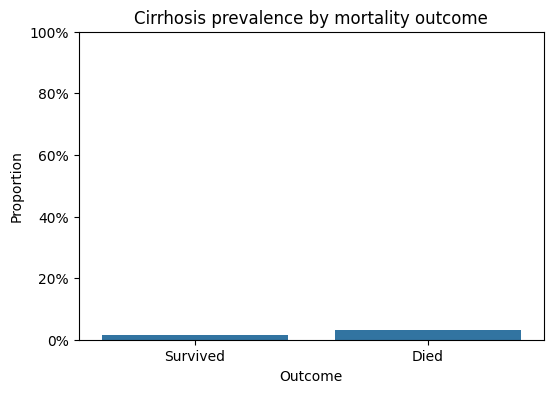

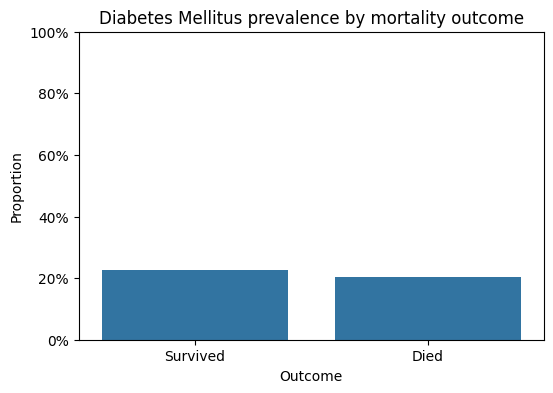

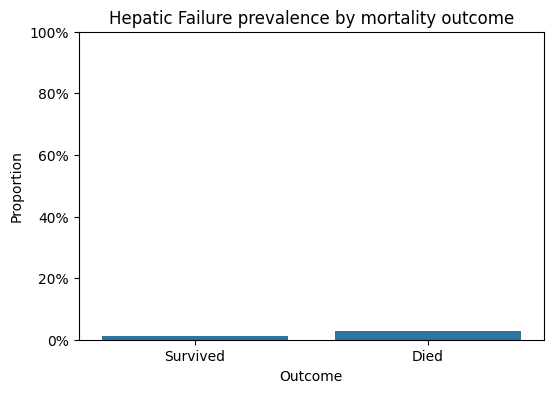

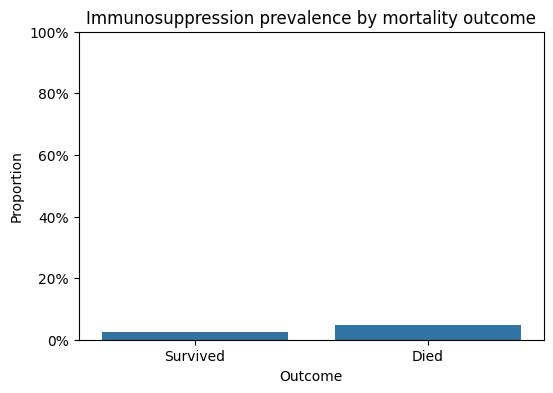

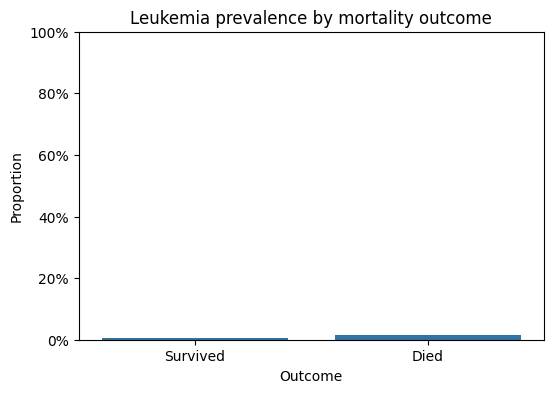

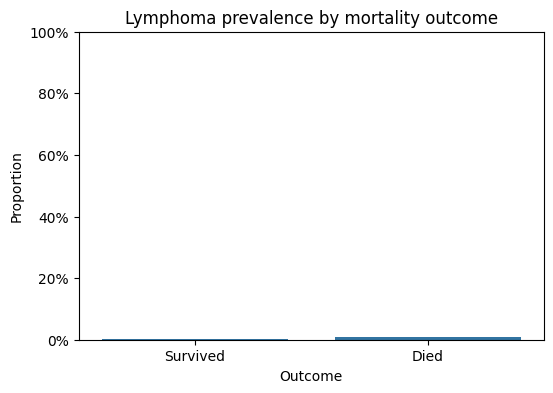

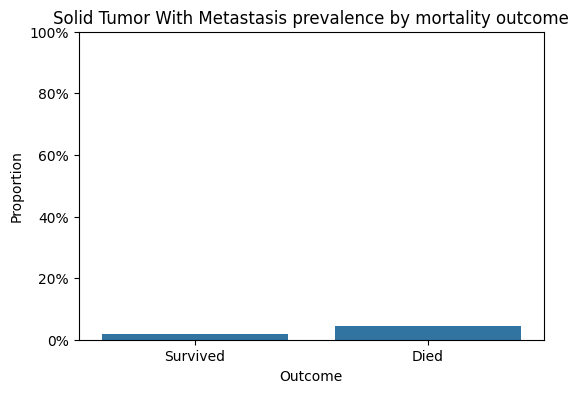

In [35]:
import matplotlib.ticker as mtick

for feature in clinical_vars:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=data,
        x="hospital_death",
        y=feature,
        errorbar=None
    )

    plt.xticks(
        [0,1],
        ["Survived", "Died"]
    )

    plt.title(f"{feature.replace('_', ' ').title()} prevalence by mortality outcome")
    plt.xlabel("Outcome")
    plt.ylabel("Proportion")
    plt.ylim(0,1)
    plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

    plt.show()

**5. Statistical Analysis**


*   Checking for siginificant differences in relevant groups
*   2-Sample T-Test and Mann-Whitney-U-Test for continuous variables
*   Chi-Square-Test for categorical variables
*   Cohen's d



In [43]:
# =========================
# 5. Statistical Analysis
# =========================

death_patients = data[data["hospital_death"] == 1]
non_death_patients = data[data["hospital_death"] == 0]


def compare_groups(features, test_name="welch"):

    print(f"\n{'='*60}")
    print(f"{test_name.upper()} TEST")
    print(f"{'='*60}")

    for feature in features:
        label = variable_labels.get(feature, feature)
        group1 = death_patients[feature].dropna()
        group2 = non_death_patients[feature].dropna()

        if test_name == "welch":
            statistic, p_value = stats.ttest_ind(
                group1,
                group2,
                equal_var=False
            )

        elif test_name == "mannwhitney":
            statistic, p_value = stats.mannwhitneyu(
                group1,
                group2,
                alternative="two-sided"
            )

        print(
            f"{label:<20}"
            f"Statistic = {statistic:>10.2f}"
            f"   p = {p_value:.3e}"
        )
def compare_categorical(features):

    print(f"\n{'='*60}")
    print("CHI-SQUARE TEST")
    print(f"{'='*60}")

    for feature in features:
        label = variable_labels.get(feature, feature)
        table = pd.crosstab(
            data[feature],
            data["hospital_death"]
        )

        chi2, p_value, dof, expected = stats.chi2_contingency(table)

        print(
            f"{label:<25}"
            f"Chi2={chi2:>10.2f}"
            f" p={p_value:.3e}"
        )

def cohens_d(features):

    print(f"\n{'='*60}")
    print("Cohens D")
    print(f"{'='*60}")

    for feature in features:
      label = variable_labels.get(feature, feature)
      group1 = death_patients[feature].dropna()
      group2 = non_death_patients[feature].dropna()

      n1, n2 = len(group1), len(group2)
      var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

      # Pooled standard deviation
      pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

      # Cohen's d formula
      effect_size = (np.mean(group1) - np.mean(group2)) / pooled_std

      print(
            f"{label:<20}"
            f"Cohens D = {effect_size:>10.2f}"
        )

    return


compare_groups(d1_vars, test_name="welch")
compare_groups(d1_vars, test_name="mannwhitney")
compare_categorical(clinical_vars)
cohens_d(d1_vars)


WELCH TEST
Maximum Heartrate (bpm)Statistic =      44.17   p = 0.000e+00
Minimum Heartrate (bpm)Statistic =      -0.74   p = 4.573e-01
Maximum Mean Blood Pressure (mmHg)Statistic =      -4.47   p = 7.777e-06
Minimum Mean Blood Pressure (mmHg)Statistic =     -55.91   p = 0.000e+00
Maximum Respiratory Rate (breaths/min)Statistic =      28.64   p = 9.162e-173
Minimum Respiratory Rate (breaths/min)Statistic =       5.98   p = 2.252e-09
Minimum Blood Oxygen Saturation (%)Statistic =     -36.79   p = 2.098e-274
Maximum Systolic Blood Pressure (mmHg)Statistic =      -7.32   p = 2.695e-13
Minimum Systolic Blood Pressure (mmHg)Statistic =     -59.22   p = 0.000e+00
Maximum Temperature (°C)Statistic =       1.33   p = 1.838e-01
Minimum Temperature (°C)Statistic =     -35.58   p = 2.608e-257
Minimum Albumin (g/L)Statistic =     -40.74   p = 0.000e+00
Maximum Bilirubin (µmol/l)Statistic =      16.37   p = 1.458e-58
Urea Nitrogen (mmol/l)Statistic =      44.85   p = 0.000e+00
Maximum Calcium (mmol

In [47]:
train_data, test_data = train_test_split(
    data,
    test_size=0.20,
    stratify=data["hospital_death"],
    random_state=42
)

eda_vars = [
    "age",
    "d1_heartrate_max",
    "d1_mbp_min",
    "d1_spo2_min",
    "d1_creatinine_max",
    "d1_lactate_max"
]

missing_summary = pd.DataFrame({
    "available_n": train_data[eda_vars].notna().sum(),
    "missing_pct": train_data[eda_vars].isna().mean() * 100
})

display(
    missing_summary.sort_values("missing_pct", ascending=False).round(1)
)

missing_by_outcome = (
    train_data[eda_vars]
    .isna()
    .groupby(train_data["hospital_death"])
    .mean()
    .mul(100)
    .T
)

missing_by_outcome.columns = [
    "missing_survived_pct",
    "missing_died_pct"
]

display(missing_by_outcome.round(1))

,available_n,missing_pct
d1_lactate_max,18724,74.5
d1_creatinine_max,65255,11.1
age,69926,4.7
d1_spo2_min,73101,0.4
d1_mbp_min,73195,0.2
d1_heartrate_max,73251,0.2


,missing_survived_pct,missing_died_pct
age,4.3,8.4
d1_heartrate_max,0.2,0.2
d1_mbp_min,0.2,0.3
d1_spo2_min,0.3,0.6
d1_creatinine_max,11.1,10.6
d1_lactate_max,76.9,49.1


Missingness differed by mortality outcome, particularly for maximum day-one lactate: values were missing in 76.9% of survivors and 49.1% of non-survivors. Lactate availability was therefore associated with the outcome. Comparisons of observed lactate values describe a selected subset of patients and should be reported alongside the number of available observations. The reasons for missingness cannot be determined from this analysis alone.

In [48]:
summary = (
    train_data
    .groupby("hospital_death")[eda_vars]
    .agg(["count", "median", "min", "max"])
    .T
)

summary.columns = ["Survived", "Died"]
display(summary.round(2))

Survived     Died
age               count   64123.00  5803.00
                  median     64.00    71.00
                  min        16.00    16.00
                  max        89.00    89.00
d1_heartrate_max  count   66933.00  6318.00
                  median    100.00   114.00
                  min        58.00    58.00
                  max       177.00   177.00
d1_mbp_min        count   66885.00  6310.00
                  median     65.00    54.00
                  min        22.00    22.00
                  max       112.00   112.00
d1_spo2_min       count   66808.00  6293.00
                  median     93.00    90.00
                  min         0.00     0.00
                  max       100.00   100.00
d1_creatinine_max count   59597.00  5658.00
                  median      0.99     1.55
                  min         0.34     0.34
                  max        11.11    11.11
d1_lactate_max    count   15499.00  3225.00
                  median      1.70     3.60
                  min         0.40     0.40
                  max        19.80    19.80

In [49]:
quartiles = (
    train_data
    .groupby("hospital_death")[["d1_mbp_min", "d1_lactate_max"]]
    .quantile([0.25, 0.50, 0.75])
)
display(quartiles)

spo2_check = train_data.groupby("hospital_death")["d1_spo2_min"].agg(
    available_n="count",
    zero_n=lambda values: values.eq(0).sum()
)
spo2_check["zero_pct_of_available"] = (
    100 * spo2_check["zero_n"] / spo2_check["available_n"]
)
display(spo2_check.round(2))

d1_mbp_min  d1_lactate_max
hospital_death                                 
0              0.25        56.0             1.1
               0.50        65.0             1.7
               0.75        75.0             2.8
1              0.25        44.0             1.9
               0.50        54.0             3.6
               0.75        65.0             7.7

,available_n,zero_n,zero_pct_of_available
hospital_death,,,
0,66808,91,0.14
1,6293,38,0.60


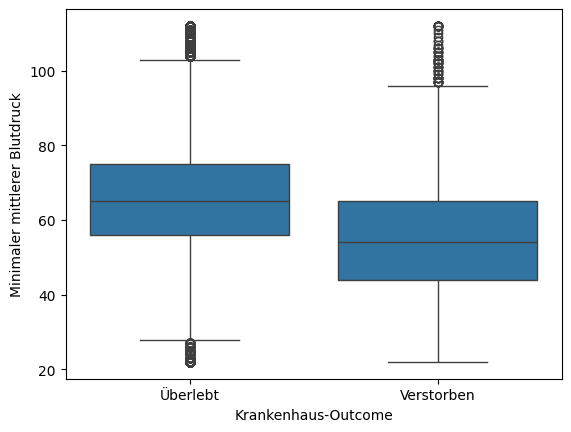

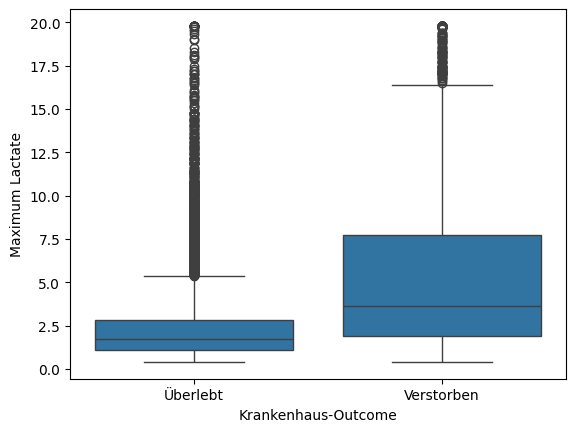

In [50]:
sns.boxplot(
    data=train_data,
    x="hospital_death",
    y="d1_mbp_min"
)

plt.xticks([0, 1], ["Überlebt", "Verstorben"])
plt.xlabel("Krankenhaus-Outcome")
plt.ylabel("Minimaler mittlerer Blutdruck")
plt.show()

sns.boxplot(
    data=train_data,
    x="hospital_death",
    y="d1_lactate_max"
)

plt.xticks([0, 1], ["Überlebt", "Verstorben"])
plt.xlabel("Krankenhaus-Outcome")
plt.ylabel("Maximum Lactate")
plt.show()

Patients who died in hospital had a lower median minimum day-one mean blood pressure and a higher median maximum day-one lactate than survivors. The distributions overlapped, so neither variable alone clearly separated the two groups. Lactate results should be interpreted cautiously because values were missing for many patients, particularly survivors.

Statistical comparisons identified differences between survivors and non-survivors across several variables. Minimum day-one mean blood pressure was lower among non-survivors (Cohen’s d = −0.71), while maximum day-one lactate was higher (d = 1.15).

Many p-values were very small, but statistical significance did not always indicate a substantial difference. For example, maximum mean blood pressure had a small effect size (d = −0.06) despite a statistically significant Welch test.

These results are exploratory and do not establish causation or predictive performance. Lactate findings apply only to patients with available measurements, and missingness differed between outcome groups. Multiple comparisons were performed without adjustment.